In [1]:
from accelerate import *
import os

In [2]:
foldername  = f'../build/output'
filenames   = [os.path.join(foldername,filename) for filename in os.listdir(foldername)]

# Print the number of files found
print(f'Found {len(filenames)} data files in {foldername}')

Found 4096 data files in ../build/output


In [3]:
files = loadFiles([filename for filename in filenames])
files = pd.concat(files)
files

loadFile:   0%|          | 0/4096 [00:00<?, ?it/s]

,EventID,TrackID,MigrantID,Particle,InitialEnergy,DepositedEnergy,XPosition,YPosition,ZPosition,LocalTime,Volume,ParentVolume,ParentID,ProcessName,filename
0,6987,9,-1,e-,3.619920,0.003209,-118.256,-112.931,126.952,6.546840,detectLogical_PV,aluminum_ascii_PV,6,phot,../build/output/APXS-run0-rank2157_nt_hits.csv
1,6987,9,-1,e-,3.619920,0.000000,-118.256,-112.931,126.952,6.546840,detectLogical_PV,aluminum_ascii_PV,6,phot,../build/output/APXS-run0-rank2157_nt_hits.csv
2,6987,9,-1,e-,3.611810,0.008105,-118.256,-112.931,126.952,6.546840,detectLogical_PV,aluminum_ascii_PV,6,phot,../build/output/APXS-run0-rank2157_nt_hits.csv
3,6987,9,-1,e-,3.435120,0.176692,-118.256,-112.931,126.952,6.546840,detectLogical_PV,aluminum_ascii_PV,6,phot,../build/output/APXS-run0-rank2157_nt_hits.csv
4,6987,9,-1,e-,3.090480,0.344641,-118.256,-112.931,126.952,6.546840,detectLogical_PV,aluminum_ascii_PV,6,phot,../build/output/APXS-run0-rank2157_nt_hits.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,258643,7,-1,e-,0.157137,0.051312,-121.135,-108.874,126.452,0.321562,detectLogical_PV,world_volume_PV,1,RadioactiveDecay,../build/output/APXS-run0-rank1862_nt_hits.csv
413,258643,7,-1,e-,0.157137,0.000000,-121.135,-108.874,126.452,0.321562,detectLogical_PV,world_volume_PV,1,RadioactiveDecay,../build/output/APXS-run0-rank1862_nt_hits.csv
414,258643,7,-1,e-,0.136202,0.020935,-121.135,-108.874,126.452,0.321562,detectLogical_PV,world_volume_PV,1,RadioactiveDecay,../build/output/APXS-run0-rank1862_nt_hits.csv
415,258643,7,-1,e-,0.136202,0.000000,-121.135,-108.874,126.452,0.321562,detectLogical_PV,world_volume_PV,1,RadioactiveDecay,../build/output/APXS-run0-rank1862_nt_hits.csv


In [12]:
gamma = files[files.Particle == 'gamma']
gamma = gamma.groupby(['EventID'])['InitialEnergy'].max().reset_index()
# gamma = gamma[gamma.InitialEnergy > 0.0]
gamma

,EventID,InitialEnergy
0,3,0.0
1,21,0.0
2,32,0.0
3,40,0.0
4,91,0.0
...,...,...
23069,262095,0.0
23070,262106,0.0
23071,262114,0.0
23072,262133,0.0


In [4]:
df = files.copy()

filename_col = 'Filename' if 'Filename' in df.columns else ('filename' if 'filename' in df.columns else None)
energy_col = 'EnergyDeposited' if 'EnergyDeposited' in df.columns else 'DepositedEnergy'

if 'ParentID' in df.columns:
    working = df.loc[df['ParentID'] > 0].copy()
else:
    working = df.copy()

working = working[working['Particle'].isin(['gamma', 'e-', 'e+'])].copy()

mask = working['Particle'].isin(['e-', 'e+'])
if 'ParentID' in working.columns:
    working.loc[mask, 'TrackID'] = working.loc[mask, 'ParentID'].to_numpy()

if filename_col is not None and filename_col in working.columns:
    group_cols = [filename_col, 'EventID', 'TrackID']
else:
    group_cols = ['EventID', 'TrackID']

gamma = (working.groupby(group_cols)
               .filter(lambda group: 'gamma' in group['Particle'].values)
               .copy())

gamma = (gamma.groupby(group_cols, as_index=False)[energy_col]
             .sum()
             .rename(columns={energy_col: 'TotalDepositedEnergy'}))

gamma.head()


,filename,EventID,TrackID,TotalDepositedEnergy
0,../build/output/APXS-run0-rank0_nt_hits.csv,5816,4,5.892546
1,../build/output/APXS-run0-rank0_nt_hits.csv,58108,5,5.161363
2,../build/output/APXS-run0-rank0_nt_hits.csv,60893,4,5.124971
3,../build/output/APXS-run0-rank0_nt_hits.csv,66407,6,5.325412
4,../build/output/APXS-run0-rank0_nt_hits.csv,128359,6,5.129101


(array([1.930e+02, 2.100e+01, 5.000e+00, 0.000e+00, 2.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 2.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 2.000e+01,
        3.800e+01, 7.000e+01, 7.400e+01, 1.800e+02, 2.390e+02, 2.270e+02,
        5.600e+01, 2.310e+02, 2.200e+02, 5.000e+00, 8.000e+00, 1.000e+00,
        3.000e+00, 4.000e+00, 5.000e+00, 4.000e+00, 3.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 5.000e+00, 1.000e+00,
        1.000e+00, 3.000e+00, 7.000e+00, 7.000e+00, 1.000e+01, 2.300e+01,
        2.100e+01, 3.600e+01, 4.100e+01, 6.800e+01, 8.300e+01, 1.020e+02,
        9.000e+01, 1.470e+02, 1.120e+02, 1.400e+02, 1.750e+02, 1.480e+02,
        7.300e+01, 1.200e+02, 7.600e+01, 1.400e+01, 2.500e+01, 1.500e+01,
        2.600e+01, 2.600e+01, 1.500e+01, 4.000e+01, 4.900e+01, 5.300e+01,
        7.900e+01, 1.500e+02, 2.220e+02, 3.730e+02, 5.860e+02, 7.600e+02,
        9.920e+02, 1.447e+03, 1.791e+0

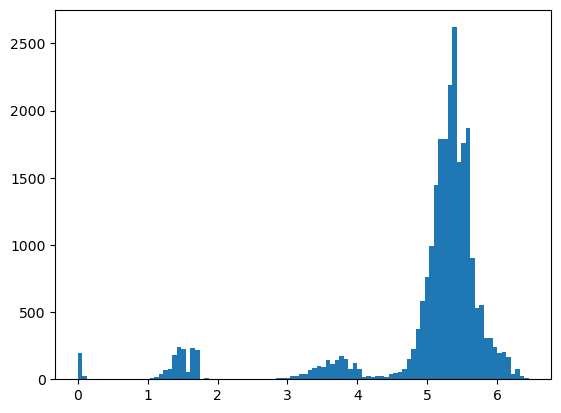

In [7]:
plt.hist(gamma['TotalDepositedEnergy'], bins=100)
